In [ ]:
!pip install pandas numpy scikit-learn scipy joblib

In [ ]:
from google.colab import files

uploaded = files.upload()

Saving KDDTest+.arff to KDDTest+.arff


In [ ]:
import pandas as pd

data = []

with open("KDDTest+.arff", "r") as f:
    for line in f:
        line = line.strip()

        # skip header lines
        if line.startswith("@") or line == "":
            continue

        data.append(line.split(","))

df = pd.DataFrame(data)

print("Dataset Loaded Successfully")
print(df.head())

Dataset Loaded Successfully
  0     1         2     3      4   5  6  7  8  9   ...  32    33    34    35  \
0  0   tcp   private   REJ      0   0  0  0  0  0  ...  10  0.04  0.06  0.00   
1  0   tcp   private   REJ      0   0  0  0  0  0  ...   1  0.00  0.06  0.00   
2  2   tcp  ftp_data    SF  12983   0  0  0  0  0  ...  86  0.61  0.04  0.61   
3  0  icmp     eco_i    SF     20   0  0  0  0  0  ...  57  1.00  0.00  1.00   
4  1   tcp    telnet  RSTO      0  15  0  0  0  0  ...  86  0.31  0.17  0.03   

     36    37    38    39    40       41  
0  0.00  0.00  0.00  1.00  1.00  anomaly  
1  0.00  0.00  0.00  1.00  1.00  anomaly  
2  0.02  0.00  0.00  0.00  0.00   normal  
3  0.28  0.00  0.00  0.00  0.00  anomaly  
4  0.02  0.00  0.00  0.83  0.71  anomaly  

[5 rows x 42 columns]


In [ ]:
columns = [
'duration','protocol_type','service','flag','src_bytes','dst_bytes','land',
'wrong_fragment','urgent','hot','num_failed_logins','logged_in',
'num_compromised','root_shell','su_attempted','num_root','num_file_creations',
'num_shells','num_access_files','num_outbound_cmds','is_host_login',
'is_guest_login','count','srv_count','serror_rate','srv_serror_rate',
'rerror_rate','srv_rerror_rate','same_srv_rate','diff_srv_rate',
'srv_diff_host_rate','dst_host_count','dst_host_srv_count',
'dst_host_same_srv_rate','dst_host_diff_srv_rate',
'dst_host_same_src_port_rate','dst_host_srv_diff_host_rate',
'dst_host_serror_rate','dst_host_srv_serror_rate','dst_host_rerror_rate',
'dst_host_srv_rerror_rate','class'
]

df.columns = columns

print("Columns assigned successfully")
print(df.head())

Columns assigned successfully
  duration protocol_type   service  flag src_bytes dst_bytes land  \
0        0           tcp   private   REJ         0         0    0   
1        0           tcp   private   REJ         0         0    0   
2        2           tcp  ftp_data    SF     12983         0    0   
3        0          icmp     eco_i    SF        20         0    0   
4        1           tcp    telnet  RSTO         0        15    0   

  wrong_fragment urgent hot  ... dst_host_srv_count dst_host_same_srv_rate  \
0              0      0   0  ...                 10                   0.04   
1              0      0   0  ...                  1                   0.00   
2              0      0   0  ...                 86                   0.61   
3              0      0   0  ...                 57                   1.00   
4              0      0   0  ...                 86                   0.31   

  dst_host_diff_srv_rate dst_host_same_src_port_rate  \
0                   0.06      

In [ ]:
print(df.shape)
print(df['class'].value_counts())

(22544, 42)
class
anomaly    12833
normal      9711
Name: count, dtype: int64


In [ ]:
df['class'] = df['class'].str.replace('.', '', regex=False)

print(df['class'].unique())

['anomaly' 'normal']


In [ ]:
df['attack_flag'] = df['class'].apply(lambda x: 0 if x == 'normal' else 1)

print(df[['class','attack_flag']].head())

     class  attack_flag
0  anomaly            1
1  anomaly            1
2   normal            0
3  anomaly            1
4  anomaly            1


In [ ]:
from sklearn.preprocessing import LabelEncoder

le_protocol = LabelEncoder()
le_service = LabelEncoder()
le_flag = LabelEncoder()

df['protocol_type'] = le_protocol.fit_transform(df['protocol_type'])
df['service'] = le_service.fit_transform(df['service'])
df['flag'] = le_flag.fit_transform(df['flag'])

print("Categorical features encoded")

Categorical features encoded


In [ ]:
X = df.drop(['class','attack_flag'], axis=1)

y_binary = df['attack_flag']   # normal vs attack
y_multi = df['class']          # attack type

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y_binary, test_size=0.3, random_state=42
)

In [ ]:
from sklearn.ensemble import RandomForestClassifier

anomaly_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

anomaly_model.fit(X_train, y_train)

print("Anomaly Detection Model Trained")

Anomaly Detection Model Trained


In [ ]:
X_train2, X_test2, y_train2, y_test2 = train_test_split(
    X, y_multi, test_size=0.3, random_state=42
)

attack_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

attack_model.fit(X_train2, y_train2)

print("Attack Classification Model Trained")

Attack Classification Model Trained


In [ ]:
from sklearn.metrics import accuracy_score

pred = anomaly_model.predict(X_test)

accuracy = accuracy_score(y_test, pred)

print("Anomaly Detection Accuracy:", accuracy)

Anomaly Detection Accuracy: 0.986989946777055


In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score
import numpy as np

# 1. Initialize with stronger regularization to prevent overfitting
rf_model = RandomForestClassifier(
    n_estimators=200,      # Increased from 100 for better stability
    max_depth=12,          # Slightly increased but restricted to prevent deep memorization
    min_samples_split=15,  # Requires more samples to create a split
    min_samples_leaf=8,    # Higher leaf requirement smooths the model
    max_features='sqrt',   # Limits features per tree to reduce correlation
    random_state=42,
    n_jobs=-1              # Uses all CPU cores for speed
)

# 2. Perform 5-Fold Cross-Validation
# This tests the model on 5 different versions of the data to ensure "Perfect Fit"
cv_scores = cross_val_score(rf_model, X, y_binary, cv=5)

# 3. Train the final model
rf_model.fit(X_train, y_train)

print(f"Cross-Validation Mean Accuracy: {np.mean(cv_scores):.4f}")
print(f"Standard Deviation of Accuracy: {np.std(cv_scores):.4f}")

Cross-Validation Mean Accuracy: 0.9831
Standard Deviation of Accuracy: 0.0010


In [ ]:
from sklearn.metrics import accuracy_score

train_preds = rf_model.predict(X_train)
test_preds = rf_model.predict(X_test)

train_acc = accuracy_score(y_train, train_preds)
test_acc = accuracy_score(y_test, test_preds)

print(f"Training Accuracy: {train_acc:.4f}")
print(f"Testing Accuracy: {test_acc:.4f}")
print(f"Gap: {abs(train_acc - test_acc):.4f}")

if abs(train_acc - test_acc) > 0.05:
    print("Warning: Model is still Overfitting (Gap > 5%)")
else:
    print("Success: Model is generalized (Robust Fit)")

Training Accuracy: 0.9862
Testing Accuracy: 0.9814
Gap: 0.0049
Success: Model is generalized (Robust Fit)


In [ ]:
# Predict and evaluate only the Random Forest
pred = rf_model.predict(X_test)
acc = accuracy_score(y_test, pred)

print(f"Random Forest Accuracy: {acc:.4f}")

Random Forest Accuracy: 0.9814


In [ ]:
def hybrid_ids(input_data):

    import pandas as pd

    sample_df = pd.DataFrame([input_data])

    sig_result = signature_detection(input_data)

    anomaly_pred = anomaly_model.predict(sample_df)[0]

    if anomaly_pred == 0:
        return "Normal Traffic"

    else:
        attack_type = attack_model.predict(sample_df)[0]

        return f"Attack Detected → {attack_type} | Signature: {sig_result}"

In [ ]:
sample_input = X.iloc[0].to_dict()

print(sample_input)

{'duration': 0.0, 'protocol_type': 1.0, 'service': 45.0, 'flag': 1.0, 'src_bytes': 0.0, 'dst_bytes': 0.0, 'land': 0.0, 'wrong_fragment': 0.0, 'urgent': 0.0, 'hot': 0.0, 'num_failed_logins': 0.0, 'logged_in': 0.0, 'num_compromised': 0.0, 'root_shell': 0.0, 'su_attempted': 0.0, 'num_root': 0.0, 'num_file_creations': 0.0, 'num_shells': 0.0, 'num_access_files': 0.0, 'num_outbound_cmds': 0.0, 'is_host_login': 0.0, 'is_guest_login': 0.0, 'count': 229.0, 'srv_count': 10.0, 'serror_rate': 0.0, 'srv_serror_rate': 0.0, 'rerror_rate': 1.0, 'srv_rerror_rate': 1.0, 'same_srv_rate': 0.04, 'diff_srv_rate': 0.06, 'srv_diff_host_rate': 0.0, 'dst_host_count': 255.0, 'dst_host_srv_count': 10.0, 'dst_host_same_srv_rate': 0.04, 'dst_host_diff_srv_rate': 0.06, 'dst_host_same_src_port_rate': 0.0, 'dst_host_srv_diff_host_rate': 0.0, 'dst_host_serror_rate': 0.0, 'dst_host_srv_serror_rate': 0.0, 'dst_host_rerror_rate': 1.0, 'dst_host_srv_rerror_rate': 1.0}


In [ ]:
# Convert all columns except categorical and class into numeric

categorical_cols = ['protocol_type','service','flag','class']

for col in df.columns:
    if col not in categorical_cols:
        df[col] = pd.to_numeric(df[col])

print("Numeric conversion completed")
print(df.dtypes)

Numeric conversion completed
duration                         int64
protocol_type                    int64
service                          int64
flag                             int64
src_bytes                        int64
dst_bytes                        int64
land                             int64
wrong_fragment                   int64
urgent                           int64
hot                              int64
num_failed_logins                int64
logged_in                        int64
num_compromised                  int64
root_shell                       int64
su_attempted                     int64
num_root                         int64
num_file_creations               int64
num_shells                       int64
num_access_files                 int64
num_outbound_cmds                int64
is_host_login                    int64
is_guest_login                   int64
count                            int64
srv_count                        int64
serror_rate                    floa

In [ ]:
from sklearn.preprocessing import LabelEncoder

le_protocol = LabelEncoder()
le_service = LabelEncoder()
le_flag = LabelEncoder()

df['protocol_type'] = le_protocol.fit_transform(df['protocol_type'])
df['service'] = le_service.fit_transform(df['service'])
df['flag'] = le_flag.fit_transform(df['flag'])

print("Categorical features encoded")

Categorical features encoded


In [ ]:
from sklearn.metrics import accuracy_score

pred = anomaly_model.predict(X_test)

accuracy = accuracy_score(y_test, pred)

print("Anomaly Detection Accuracy:", accuracy)

Anomaly Detection Accuracy: 0.986989946777055


In [ ]:
def signature_detection(sample):

    if sample['src_bytes'] > 8000 and sample['dst_bytes'] == 0:
        return "Possible DoS Attack"

    if sample['dst_host_diff_srv_rate'] > 0.7:
        return "Probe / Scan Attack"

    if sample['dst_host_rerror_rate'] > 0.6:
        return "Connection Error Attack"

    if sample['logged_in'] == 0 and sample['dst_bytes'] < 100:
        return "Possible Login Attack"

    return "No Signature Match"

In [ ]:
def hybrid_ids(input_data):

    import pandas as pd

    sample_df = pd.DataFrame([input_data])

    sig_result = signature_detection(input_data)

    anomaly_pred = anomaly_model.predict(sample_df)[0]

    if anomaly_pred == 0:
        return "Normal Traffic"

    else:
        attack_type = attack_model.predict(sample_df)[0]

        return f"Attack Detected → {attack_type} | Signature: {sig_result}"

In [ ]:
result = hybrid_ids(sample_input)

print("Prediction Result:")
print(result)

Prediction Result:
Attack Detected → anomaly | Signature: Connection Error Attack


In [ ]:
test_sample = X.iloc[10].to_dict()

prediction = hybrid_ids(test_sample)

print("Hybrid IDS Output:")
print(prediction)

Hybrid IDS Output:
Attack Detected → anomaly | Signature: Connection Error Attack


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

importances = anomaly_model.feature_importances_
features = X.columns

importance_df = pd.DataFrame({
    "Feature": features,
    "Importance": importances
})

importance_df = importance_df.sort_values(by="Importance", ascending=False)

print(importance_df.head(15))

                        Feature  Importance
4                     src_bytes    0.175923
5                     dst_bytes    0.121337
33       dst_host_same_srv_rate    0.081440
34       dst_host_diff_srv_rate    0.065131
2                       service    0.063408
32           dst_host_srv_count    0.058933
39         dst_host_rerror_rate    0.055683
0                      duration    0.041986
3                          flag    0.034692
11                    logged_in    0.034014
40     dst_host_srv_rerror_rate    0.033671
1                 protocol_type    0.030660
35  dst_host_same_src_port_rate    0.027893
23                    srv_count    0.023171
22                        count    0.017409


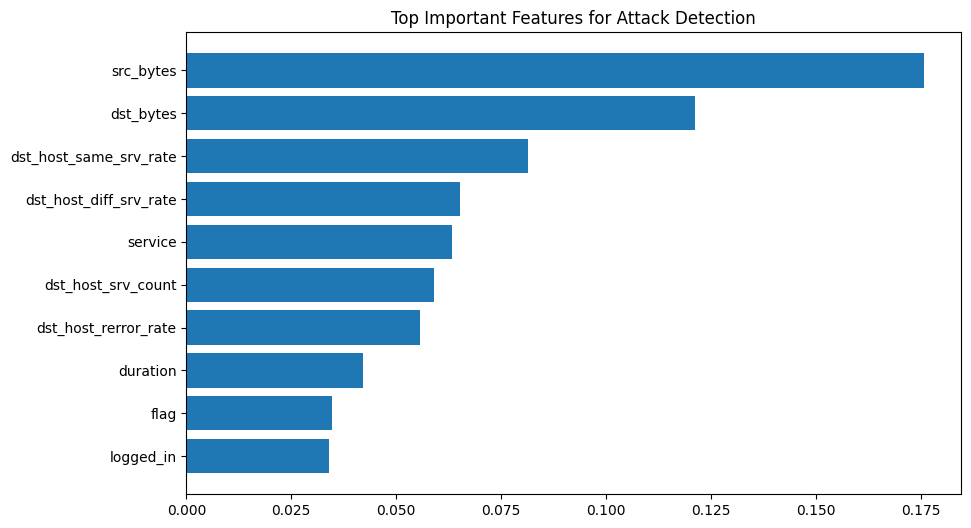

In [ ]:
plt.figure(figsize=(10,6))
plt.barh(importance_df["Feature"][:10], importance_df["Importance"][:10])
plt.gca().invert_yaxis()
plt.title("Top Important Features for Attack Detection")
plt.show()

In [ ]:
important_features = [
'src_bytes',
'dst_bytes',
'dst_host_same_srv_rate',
'dst_host_diff_srv_rate',
'service',
'dst_host_srv_count',
'dst_host_rerror_rate',
'duration',
'flag',
'logged_in'
]

<Figure size 800x600 with 0 Axes>

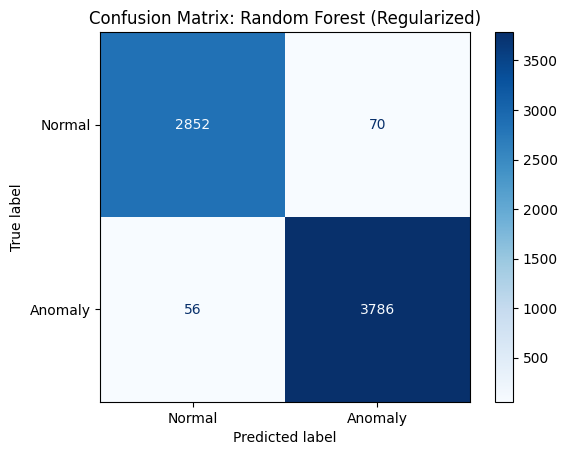

True Negatives (Correctly identified Normal): 2852
False Positives (Normal identified as Attack): 70
False Negatives (Attack identified as Normal): 56
True Positives (Correctly identified Attack): 3786


In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# 1. Generate the Confusion Matrix
# Using 'test_preds' from our previous regularization step
cm = confusion_matrix(y_test, test_preds)

# 2. Visualize the Matrix
plt.figure(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Normal', 'Anomaly'])
disp.plot(cmap=plt.cm.Blues)

plt.title("Confusion Matrix: Random Forest (Regularized)")
plt.show()

# 3. Print the specific breakdown
tn, fp, fn, tp = cm.ravel()
print(f"True Negatives (Correctly identified Normal): {tn}")
print(f"False Positives (Normal identified as Attack): {fp}")
print(f"False Negatives (Attack identified as Normal): {fn}")
print(f"True Positives (Correctly identified Attack): {tp}")

In [ ]:
def get_user_input():

    data = {}

    print("Enter Network Traffic Details")

    data['src_bytes'] = int(input("Source Bytes: "))
    data['dst_bytes'] = int(input("Destination Bytes: "))
    data['dst_host_same_srv_rate'] = float(input("Same Service Rate (0-1): "))
    data['dst_host_diff_srv_rate'] = float(input("Different Service Rate (0-1): "))
    data['service'] = int(input("Service Type (encoded number): "))
    data['dst_host_srv_count'] = int(input("Destination Host Service Count: "))
    data['dst_host_rerror_rate'] = float(input("Destination Host Error Rate (0-1): "))
    data['duration'] = int(input("Connection Duration: "))
    data['flag'] = int(input("Connection Flag (encoded number): "))
    data['logged_in'] = int(input("Logged In (0 or 1): "))

    return data

In [ ]:
def prepare_full_input(user_input):

    sample = X.mean().to_dict()

    for key in user_input:
        sample[key] = user_input[key]

    return sample

In [ ]:
print(df['attack_flag'].value_counts())

attack_flag
1    12833
0     9711
Name: count, dtype: int64


In [ ]:
X.describe()

,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_count,dst_host_srv_count,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate
count,22544.000000,22544.000000,22544.000000,22544.000000,2.254400e+04,2.254400e+04,22544.000000,22544.000000,22544.000000,22544.000000,...,22544.000000,22544.000000,22544.000000,22544.000000,22544.000000,22544.000000,22544.000000,22544.000000,22544.000000,22544.000000
mean,218.859076,1.069996,31.629879,6.874157,1.039545e+04,2.056019e+03,0.000311,0.008428,0.000710,0.105394,...,193.869411,140.750532,0.608722,0.090540,0.132261,0.019638,0.097814,0.099426,0.233385,0.226683
std,1407.176612,0.397032,14.315780,3.210074,4.727864e+05,2.121930e+04,0.017619,0.142599,0.036473,0.928428,...,94.035663,111.783972,0.435688,0.220717,0.306268,0.085394,0.273139,0.281866,0.387229,0.400875
min,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,1.000000,22.000000,5.000000,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000,0.000000,...,121.000000,15.000000,0.070000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,1.000000,22.000000,9.000000,5.400000e+01,4.600000e+01,0.000000,0.000000,0.000000,0.000000,...,255.000000,168.000000,0.920000,0.010000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,0.000000,1.000000,45.000000,9.000000,2.870000e+02,6.010000e+02,0.000000,0.000000,0.000000,0.000000,...,255.000000,255.000000,1.000000,0.060000,0.030000,0.010000,0.000000,0.000000,0.360000,0.170000
max,57715.000000,2.000000,63.000000,10.000000,6.282565e+07,1.345927e+06,1.000000,3.000000,3.000000,101.000000,...,255.000000,255.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [ ]:
user_input = get_user_input()

sample = prepare_full_input(user_input)

prediction = hybrid_ids(sample)

print("\nHybrid IDS Prediction Result:")
print(prediction)

Enter Network Traffic Details
Source Bytes: 90
Destination Bytes: 56
Same Service Rate (0-1): 5
Different Service Rate (0-1): 4
Service Type (encoded number): 4
Destination Host Service Count: 4
Destination Host Error Rate (0-1): 4
Connection Duration: 4
Connection Flag (encoded number): 4
Logged In (0 or 1): 4

Hybrid IDS Prediction Result:
Attack Detected → anomaly | Signature: Probe / Scan Attack


In [ ]:
import joblib

joblib.dump(anomaly_model,"anomaly_model.pkl")
joblib.dump(attack_model,"attack_model.pkl")

print("Models saved successfully")

Models saved successfully


In [ ]:
import joblib

feature_means = X.mean().to_dict()

joblib.dump(feature_means,"feature_means.pkl")
joblib.dump(X.columns.tolist(),"feature_order.pkl")

print("Feature defaults saved")

Feature defaults saved
